# Detecting expr3.interval plot (0602)

Run this notebook on af309 with the `xfold-scripts` kernel. Set `RUN_ROOTS` to one or more host data directories; all roots are plotted in one figure.


In [ ]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter


# Set one or more host data directories. Each root should point to detecting.expr3.interval/. N不跟时间尺度的！
# RUN_ROOTS = [
#     Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/c920bn3/outputDetecting/expr3interval/walk5/REPLACE_20260603-102953/detecting.expr3.interval/'), #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr3Interval.0602.sh detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n5_tbase1000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n5_tbase10000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n5_tbase100000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n5_tbase1000000.csv
#     Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/camd9554n2/outputDetecting/expr3interval/walk5/REPLACE_20260603-103333/detecting.expr3.interval/'), #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr1Fsize.0602.sh  detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr1_fsize_Normal_n5_tbase1000.csv
#     Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/cgnr6760pn2/outputDetecting/expr3interval/walk5/REPLACE_20260603-103358/detecting.expr3.interval/') #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr1Fsize.0602.sh  detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr1_fsize_Normal_n5_tbase1000.csv
# ]

# RUN_ROOTS = [
#     Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/c920bn3/outputDetecting/expr3interval/walk5/REPLACE_20260603-102953/detecting.expr3.interval/'), #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr3Interval.0602.sh detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase1000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase10000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase100000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase1000000.csv
#     Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/camd9554n2/outputDetecting/expr3interval/walk5/REPLACE_20260603-103333/detecting.expr3.interval/'), #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr1Fsize.0602.sh  detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr1_fsize_Normal_n5_tbase1000.csv
#     Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/cgnr6760pn2/outputDetecting/expr3interval/walk5/REPLACE_20260603-103358/detecting.expr3.interval/') #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr1Fsize.0602.sh  detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr1_fsize_Normal_n5_tbase1000.csv
# ]

# # 0Kib
# RUN_ROOTS = [
#     Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/c920bn3/outputDetecting/expr3interval/walk20/REPLACE_20260603-131904/detecting.expr3.interval/'), #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr3Interval.0602.sh detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase1000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase10000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase100000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase1000000.csv
#     Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/camd9554n2/outputDetecting/expr3interval/walk20/REPLACE_20260603-131859/detecting.expr3.interval/'), #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr1Fsize.0602.sh  detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr1_fsize_Normal_n5_tbase1000.csv
#     Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/cgnr6760pn2/outputDetecting/expr3interval/walk20/REPLACE_20260603-131844/detecting.expr3.interval/') #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr1Fsize.0602.sh  detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr1_fsize_Normal_n5_tbase1000.csv
# ]



# 0Kib，纠正tt是tbase尺度相关，
# 920b,第1次测试，Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/c920bn3/outputDetecting/expr3interval/walk20/REPLACE_20260603-173955/detecting.expr3.interval/'), #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr3Interval.0602.sh detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase1000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase10000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase100000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase1000000.csv
# 920b,第2次测试，Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/c920bn3/outputDetecting/expr3interval/walk20/REPLACE_20260603-174756/detecting.expr3.interval/'), #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr3Interval.0602.sh detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase1000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase10000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase100000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase1000000.csv
# 920b，第3次测试，Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/c920bn3/outputDetecting/expr3interval/walk20/REPLACE_20260603-180103/detecting.expr3.interval/'), #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr3Interval.0602.sh detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase1000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase10000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase100000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase1000000.csv

# amd9554n2,1次，Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/camd9554n2/outputDetecting/expr3interval/walk20/REPLACE_20260603-184151/detecting.expr3.interval/')
# amd9554n2,2,Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/camd9554n2/outputDetecting/expr3interval/walk20/REPLACE_20260603-184716/detecting.expr3.interval/')
# amd9554n2,3,Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/camd9554n2/outputDetecting/expr3interval/walk20/REPLACE_20260603-185243/detecting.expr3.interval/')

# cgnr6760pn2,1,Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/cgnr6760pn2/outputDetecting/expr3interval/walk20/REPLACE_20260603-184203/detecting.expr3.interval/')
# cgnr6760pn2,2,Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/cgnr6760pn2/outputDetecting/expr3interval/walk20/REPLACE_20260603-185315/detecting.expr3.interval/')
# cgnr6760pn2,3,

RUN_ROOTS = [
    Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/c920bn3/outputDetecting/expr3interval/walk20/REPLACE_20260603-180103/detecting.expr3.interval/'), #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr3Interval.0602.sh detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase1000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase10000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase100000.csv /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr3_interval_Normal_n20_tbase1000000.csv
    Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/camd9554n2/outputDetecting/expr3interval/walk20/REPLACE_20260603-185243/detecting.expr3.interval/'), #camd9554n2 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr1Fsize.0602.sh  detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr1_fsize_Normal_n5_tbase1000.csv
    Path('/astrum/home/hpchzy/code/data/REPLACE_20260603/cgnr6760pn2/outputDetecting/expr3interval/walk20/REPLACE_20260603-185315/detecting.expr3.interval/') #920bn3 手动测试1, n(0,1)*1000, fix 2.9GHz，5walks，tbase1000，./run_entry_detecting.expr1Fsize.0602.sh  detect /home/hpchzy/code/TacVar/scripts/walklists/detecting_expr1_fsize_Normal_n5_tbase1000.csv
]




REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "scripts":
    REPO_ROOT = REPO_ROOT.parent
OUT_DIR = REPO_ROOT / "scripts_plot/outputDetecting"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# RL_RH_NQUANT = 1000
# RL_RH_DELTA = 5
# RL_RH_Q = 0.9

TIMER_COLORS = {
    "tsc": "tab:blue",
    "tsc_asym": "tab:cyan",
    "clock_gettime": "tab:orange",
    "mpi_wtime": "tab:green",
    "papi": "tab:red",
    "papix6": "tab:purple",
    "likwid": "tab:brown",
    "cntvct": "tab:cyan",
    "cntvct_fence": "tab:olive",
    "cntvcto": "tab:pink",
}

RUN_TAG = "multi_host" if len(RUN_ROOTS) > 1 else RUN_ROOTS[0].name

for root in RUN_ROOTS:
    print(root)

/astrum/home/hpchzy/code/data/20260603/c920bn3/outputDetecting/expr3interval/walk20/20260603-174756/detecting.expr3.interval
/astrum/home/hpchzy/code/data/20260603/camd9554n2/outputDetecting/expr3interval/walk20/20260603-184716/detecting.expr3.interval
/astrum/home/hpchzy/code/data/20260603/cgnr6760pn2/outputDetecting/expr3interval/walk20/20260603-185315/detecting.expr3.interval


In [22]:
def parse_meta(path):
    d = {}
    if not path.exists():
        return d
    for line in path.read_text(errors="ignore").splitlines():
        if "=" in line:
            k, v = line.split("=", 1)
            d[k.strip()] = v.strip()
    return d


def read_values(path):
    vals = []
    for line in path.read_text(errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        try:
            vals.append(float(line.split(",")[-1]))
        except ValueError:
            pass
    return vals


def q(vals, p):
    vals = sorted(vals)
    if not vals:
        return math.nan
    if len(vals) == 1:
        return vals[0]
    pos = p * (len(vals) - 1)
    lo, hi = math.floor(pos), math.ceil(pos)
    if lo == hi:
        return vals[lo]
    return vals[lo] * (hi - pos) + vals[hi] * (pos - lo)




def local_w_hat(theory, measured, x_idx, y_idx):
    theory, measured = sorted(theory), sorted(measured)
    if not theory or not measured or x_idx > y_idx:
        return math.nan
    tau = measured[0] - theory[0]
    vals = []
    for idx in range(x_idx, y_idx + 1):
        p = (idx - 1) / (RL_RH_NQUANT - 1)
        vals.append(abs(q(measured, p) - q(theory, p) - tau))
    return float(np.mean(vals)) if vals else math.nan


def base_w_hat(vals, x_idx, y_idx):
    vals = sorted(vals)
    if not vals or x_idx > y_idx:
        return math.nan
    vmin = vals[0]
    out = []
    for idx in range(x_idx, y_idx + 1):
        p = (idx - 1) / (RL_RH_NQUANT - 1)
        out.append(abs(q(vals, p) - vmin))
    return float(np.mean(out)) if out else math.nan


def rl_rh_detail(measured, theory):
    low_num = local_w_hat(theory, measured, 1, RL_RH_Q)
    high_num = local_w_hat(theory, measured, RL_RH_Q + 1, RL_RH_NQUANT - RL_RH_DELTA)
    low_den = base_w_hat(measured, 1, RL_RH_Q)
    high_den = base_w_hat(measured, RL_RH_Q + 1, RL_RH_NQUANT - RL_RH_DELTA)
    eps = 1e-9
    rl = low_num / low_den * 100 if low_den and low_den > eps and np.isfinite(low_den) else math.nan
    rh = high_num / high_den * 100 if high_den and high_den > eps and np.isfinite(high_den) else math.nan
    return rl, rh, low_num, low_den, high_num, high_den



def drop_top_pair(measured, theory, frac):
    if frac <= 0 or not measured:
        return list(measured), list(theory)
    pairs = sorted(zip(measured, theory), key=lambda x: x[0])
    keep = max(1, int(math.floor(len(pairs) * (1.0 - frac))))
    pairs = pairs[:keep]
    return [m for m, _ in pairs], [t for _, t in pairs]

def ta_from_run_dir(run_dir, meta):
    m = re.search(r"_ta([0-9.]+)", run_dir.name)
    if m:
        return float(m.group(1))
    return float(meta.get("mu_ns", meta.get("interval_ns", 0)) or 0)


In [23]:
rows = []
for run_root in RUN_ROOTS:
    for cdf in sorted(run_root.rglob("*_ta_cdf.csv")):
        run_dir = cdf.parent
        combo_dir = run_dir.parent
        meta = parse_meta(run_dir / "meta.txt") or parse_meta(combo_dir / "meta.txt")
        measured = read_values(cdf)
        if not measured:
            continue
        ta = ta_from_run_dir(run_dir, meta)
        rows.append({
            "host": meta.get("host", run_root.parts[-5] if len(run_root.parts) >= 5 else ""),
            "expr": meta.get("expr_name", run_root.name),
            "np": int(meta.get("np", 0) or 0),
            "timer": meta.get("timer", cdf.parents[2].name),
            "interval_ns": int(float(meta.get("interval_ns", meta.get("mu_ns", 0)) or 0)),
            "fsize_kib": int(float(meta.get("fsize_kib", 0) or 0)),
            "fkern": meta.get("fkern", ""),
            "rkern": meta.get("rkern", ""),
            "ta": ta,
            "n_measured": len(measured),
            "measured": measured,
            "theory": [ta] * len(measured),
            "run_dir": str(run_dir),
            "run_root": str(run_root),
        })

raw = pd.DataFrame(rows)
print(f"roots: {len(RUN_ROOTS)}, cdf files: {len(raw)}")
raw.head()


roots: 3, cdf files: 1440


,host,expr,np,timer,interval_ns,fsize_kib,fkern,rkern,ta,n_measured,measured,theory,run_dir,run_root
0,c920bn3,detecting.expr3.interval,64,clock_gettime,1000000,0,copy,none,1000457.0,100,"[999519.0, 999520.0, 999520.0, 999520.0, 99952...","[1000457.0, 1000457.0, 1000457.0, 1000457.0, 1...",/astrum/home/hpchzy/code/data/20260603/c920bn3...,/astrum/home/hpchzy/code/data/20260603/c920bn3...
1,c920bn3,detecting.expr3.interval,64,clock_gettime,1000000,0,copy,none,998440.0,100,"[997499.0, 997509.0, 997509.0, 997509.0, 99750...","[998440.0, 998440.0, 998440.0, 998440.0, 99844...",/astrum/home/hpchzy/code/data/20260603/c920bn3...,/astrum/home/hpchzy/code/data/20260603/c920bn3...
2,c920bn3,detecting.expr3.interval,64,clock_gettime,1000000,0,copy,none,1001126.0,100,"[1000189.0, 1000190.0, 1000190.0, 1000190.0, 1...","[1001126.0, 1001126.0, 1001126.0, 1001126.0, 1...",/astrum/home/hpchzy/code/data/20260603/c920bn3...,/astrum/home/hpchzy/code/data/20260603/c920bn3...
3,c920bn3,detecting.expr3.interval,64,clock_gettime,1000000,0,copy,none,1001411.0,100,"[1000469.0, 1000470.0, 1000470.0, 1000470.0, 1...","[1001411.0, 1001411.0, 1001411.0, 1001411.0, 1...",/astrum/home/hpchzy/code/data/20260603/c920bn3...,/astrum/home/hpchzy/code/data/20260603/c920bn3...
4,c920bn3,detecting.expr3.interval,64,clock_gettime,1000000,0,copy,none,997073.0,100,"[996139.0, 996139.0, 996139.0, 996140.0, 99614...","[997073.0, 997073.0, 997073.0, 997073.0, 99707...",/astrum/home/hpchzy/code/data/20260603/c920bn3...,/astrum/home/hpchzy/code/data/20260603/c920bn3...


In [24]:
raw_filtered = raw[raw['fsize_kib'] == 0]
print(raw_filtered.head())
from scipy.stats import wasserstein_distance
import numpy as np

RL_QUANTILE_BOUNDARY = [0.0, 0.9]
RH_QUANTILE_BOUNDARY = [0.9, 0.99]

summary_rows = []
keys = ["host", "expr", "np", "timer", "interval_ns", "fkern", "rkern"]
for key, g in raw_filtered.groupby(keys, dropna=False):
    measured_raw = np.array([x for vals in g["measured"] for x in vals])
    theory_raw = np.array([x for vals in g["theory"] for x in vals])

    measured_aligned = measured_raw - np.min(measured_raw)
    theory_aligned = theory_raw - np.min(theory_raw)

    measured_rl_lb_q = np.quantile(measured_aligned, RL_QUANTILE_BOUNDARY[0])
    measured_rl_ub_q = np.quantile(measured_aligned, RL_QUANTILE_BOUNDARY[1])
    theory_rl_lb_q = np.quantile(theory_aligned, RL_QUANTILE_BOUNDARY[0])
    theory_rl_ub_q = np.quantile(theory_aligned, RL_QUANTILE_BOUNDARY[1])

    rl_numerator = wasserstein_distance(measured_aligned[(measured_aligned >= measured_rl_lb_q) & (measured_aligned <= measured_rl_ub_q)], theory_aligned[(theory_aligned >= theory_rl_lb_q) & (theory_aligned <= theory_rl_ub_q)])
    rl_denominator = wasserstein_distance(measured_aligned[(measured_aligned >= measured_rl_lb_q) & (measured_aligned <= measured_rl_ub_q)], np.zeros_like(measured_aligned))
    rl = rl_numerator / rl_denominator

    measured_rh_lb_q = np.quantile(measured_aligned, RH_QUANTILE_BOUNDARY[0])
    measured_rh_ub_q = np.quantile(measured_aligned, RH_QUANTILE_BOUNDARY[1])
    theory_rh_lb_q = np.quantile(theory_aligned, RH_QUANTILE_BOUNDARY[0])
    theory_rh_ub_q = np.quantile(theory_aligned, RH_QUANTILE_BOUNDARY[1])

    rh_numerator = wasserstein_distance(measured_aligned[(measured_aligned >= measured_rh_lb_q) & (measured_aligned <= measured_rh_ub_q)], theory_aligned[(theory_aligned >= theory_rh_lb_q) & (theory_aligned <= theory_rh_ub_q)])
    rh_denominator = wasserstein_distance(measured_aligned[(measured_aligned >= measured_rh_lb_q) & (measured_aligned <= measured_rh_ub_q)], np.zeros_like(measured_aligned))
    rh = rh_numerator / rh_denominator

    row = dict(zip(keys, key))
    row.update({
        "rl": rl,
        "rl_numerator": rl_numerator,
        "rl_denominator": rl_denominator,
        "rh": rh,
        "rh_numerator": rh_numerator,
        "rh_denominator": rh_denominator,
        "measured_q5": np.quantile(measured_aligned, 0.25),
        "measured_q25": np.quantile(measured_aligned, 0.25),
        "measured_q50": np.quantile(measured_aligned, 0.5),
        "measured_q75": np.quantile(measured_aligned, 0.75),
        "measured_q95": np.quantile(measured_aligned, 0.95),
        
        "theory_q50": np.quantile(theory_aligned, 0.50),

    })
    summary_rows.append(row)
df = pd.DataFrame(summary_rows).sort_values(["np", "timer", "interval_ns"]).reset_index(drop=True)
df = df[(df['timer'] != 'cntvct_fence') & (df['timer'] != 'tsc_asym') & (df['interval_ns'] > 0)]

mapping = {
    "cgnr6760pn2": "Intel Xeon 6760P ",
    "camd9554n2": "AMD EPYC 9554",
    "c920bn3": "Kunpeng 920B",
}

df['hostname']=df['host'].map(mapping).fillna(df['host'])
df.to_csv("demo.0602.csv", index=False)
df.head()


      host                      expr  np          timer  interval_ns  \
0  c920bn3  detecting.expr3.interval  64  clock_gettime      1000000   
1  c920bn3  detecting.expr3.interval  64  clock_gettime      1000000   
2  c920bn3  detecting.expr3.interval  64  clock_gettime      1000000   
3  c920bn3  detecting.expr3.interval  64  clock_gettime      1000000   
4  c920bn3  detecting.expr3.interval  64  clock_gettime      1000000   

   fsize_kib fkern rkern         ta  n_measured  \
0          0  copy  none  1000457.0         100   
1          0  copy  none   998440.0         100   
2          0  copy  none  1001126.0         100   
3          0  copy  none  1001411.0         100   
4          0  copy  none   997073.0         100   

                                            measured  \
0  [999519.0, 999520.0, 999520.0, 999520.0, 99952...   
1  [997499.0, 997509.0, 997509.0, 997509.0, 99750...   
2  [1000189.0, 1000190.0, 1000190.0, 1000190.0, 1...   
3  [1000469.0, 1000470.0, 1000470.0,

,host,expr,np,timer,interval_ns,fkern,rkern,rl,rl_numerator,rl_denominator,rh,rh_numerator,rh_denominator,measured_q5,measured_q25,measured_q50,measured_q75,measured_q95,theory_q50,hostname
0,c920bn3,detecting.expr3.interval,64,clock_gettime,1000,copy,none,0.842409,15.192613,18.034719,0.874532,28.751972,32.876972,10.0,10.0,20.0,20.0,30.0,3.0,Kunpeng 920B
1,camd9554n2,detecting.expr3.interval,64,clock_gettime,1000,copy,none,0.845057,15.500768,18.342873,0.953334,84.269872,88.394872,11.0,11.0,20.0,21.0,61.0,3.0,AMD EPYC 9554
2,cgnr6760pn2,detecting.expr3.interval,64,clock_gettime,1000,copy,none,0.769673,9.497339,12.339444,0.951337,80.641667,84.766667,9.0,9.0,11.0,14.0,83.0,3.0,Intel Xeon 6760P
3,c920bn3,detecting.expr3.interval,64,clock_gettime,10000,copy,none,0.288016,10.809833,37.532055,0.289634,18.143777,62.643777,30.0,30.0,41.0,51.0,61.0,30.5,Kunpeng 920B
4,camd9554n2,detecting.expr3.interval,64,clock_gettime,10000,copy,none,0.711694,65.964691,92.686913,0.891982,367.467742,411.967742,61.0,61.0,111.0,131.0,181.0,30.5,AMD EPYC 9554


/tmp/ipykernel_1278371/2949333744.py:40: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


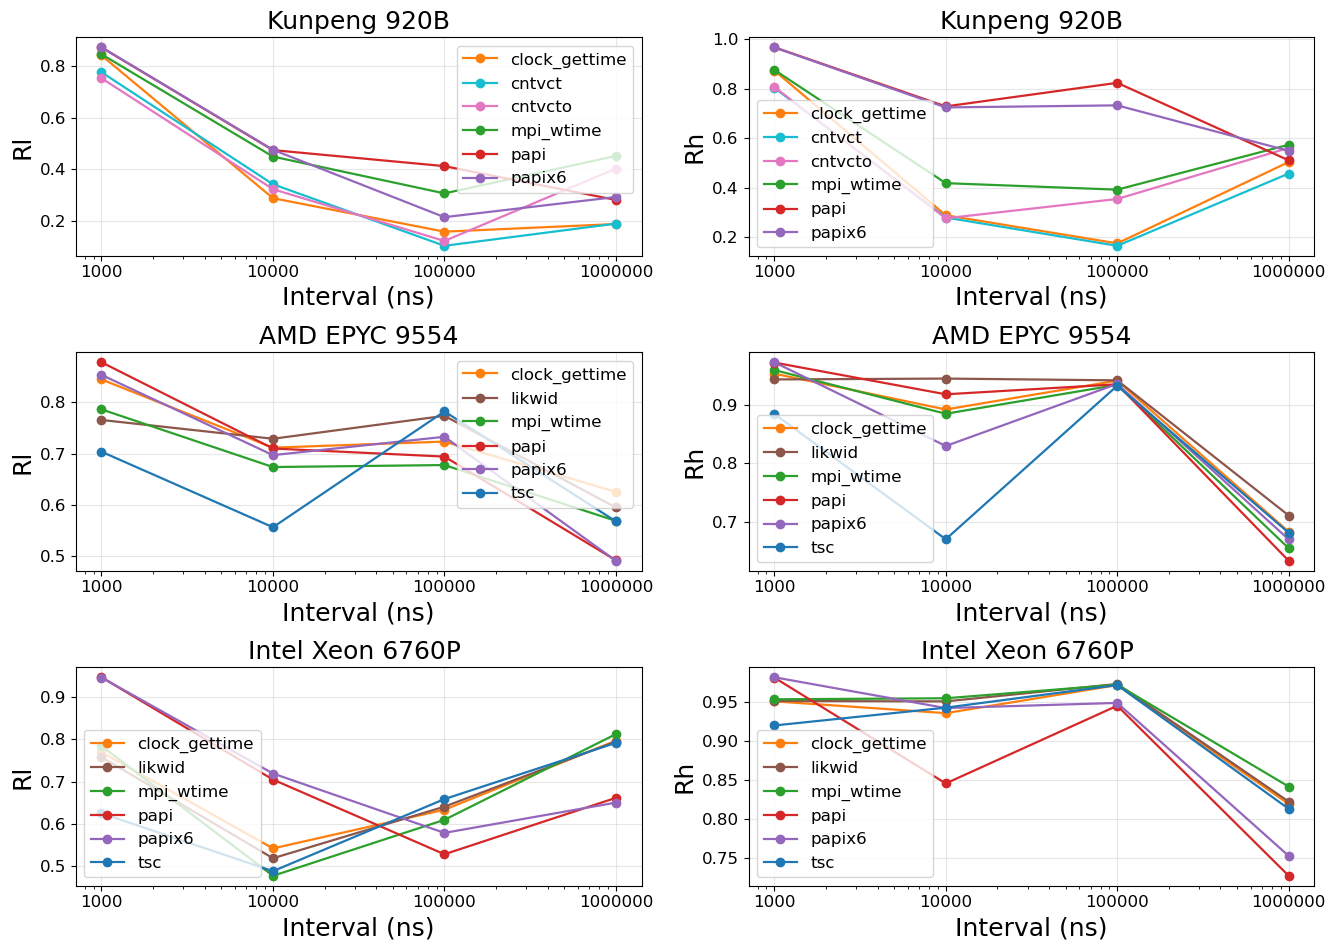

In [25]:
plot_df = df.copy()
plot_df["interval_us"] = plot_df["interval_ns"] / 1000
metrics = [("rl", "Rl"), ("rh", "Rh")]
hosts = list(plot_df["host"].dropna().drop_duplicates())
nrows = max(1, len(hosts))
fig, axes = plt.subplots(nrows, 2, figsize=(13.5, 3.2 * nrows), squeeze=False, constrained_layout=True)

interval_ticks = sorted(int(x) for x in plot_df["interval_ns"].dropna().unique())
for row_idx, host in enumerate(hosts):
    host_df = plot_df[plot_df["host"] == host]
    for col_idx, (metric, ylabel) in enumerate(metrics):
        ax = axes[row_idx][col_idx]
        for timer, g in host_df.groupby("timer"):
            g = g.sort_values("interval_ns")
            color = TIMER_COLORS.get(timer, None)
            ax.plot(g["interval_ns"], g[metric], marker="o", linewidth=1.6, label=timer, color=color)

        ax.set_xscale("log", base=10)
        ax.xaxis.set_major_locator(FixedLocator(interval_ticks))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if int(x) in interval_ticks else ""))
        ax.set_xlabel("Interval (ns)", fontsize=18)
        ax.set_ylabel(ylabel, fontsize=18)
        ax.set_title(f"{mapping.get(host)}", fontsize=18)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=12)
        ax.tick_params(axis='both', labelsize=12)
        

if plot_df.empty:
    # fig.suptitle("detecting expr3.interval")
    pass
else:
    expr = plot_df["expr"].iloc[0]
    np_val = plot_df["np"].iloc[0]
    # fig.suptitle(f"{expr} np={np_val}")

# fig.text(0.5, -0.02, " | ".join(str(p) for p in RUN_ROOTS), ha="center", va="bottom", fontsize=8)
# fig.savefig(FIG_PATH, dpi=220, bbox_inches="tight")

fig.tight_layout()
plt.show()
